Костин Арсений, 8Е21, вариант 3.

# Лабораторная работа 4b. Детектор лиц + классификатор эмоций (CNN)

Реализуем две свои нейросети на PyTorch с нуля:

**FaceDetectorCNN** — бинарный классификатор патча (лицо / фон). Применяется в режиме скользящего окна + пирамиды масштабов для нахождения лиц на произвольном изображении.

**EmotionCNN** — четырёхклассовый классификатор эмоций: `angry`, `happy`, `sad`, `surprised`. Обучается на датасете `dataset_clean` (244 изображения).

Оба — CNN с нуля (без предобученных весов). Для борьбы с переобучением на маленьком датасете: BatchNorm, Dropout, аугментация, AdaptiveAvgPool вместо FC после свёрток.

In [37]:
import numpy as np
import cv2
import os
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import skimage.data as skd

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                       'cpu'   if not torch.cuda.is_available() else 'cuda')
print('device:', DEVICE)

LABS   = Path('.')
IMG_SZ = 64
EMOTIONS = ['angry', 'happy', 'sad', 'surprised']

device: mps


## 4.1 Данные для детектора лиц

Лица берём из LFW (Labeled Faces in the Wild) — тот же датасет что и в lab4.
Негативы (не-лица) — случайные кропы из изображений skimage: текстуры, объекты, природа. Такие патчи не содержат лиц, поэтому модель учится отличать именно лицо от реального фона, а не от перевёрнутого лица.

In [38]:
print('Загружаем LFW...')
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True)
print(f'Лиц: {len(lfw.images)}, размер: {lfw.images.shape[1]}x{lfw.images.shape[2]}')

def lfw_to_uint8(imgs):
    out = []
    for img in imgs:
        u = (img * 255).astype(np.uint8)
        u = cv2.resize(u, (IMG_SZ, IMG_SZ))
        out.append(u)
    return out

pos_imgs = lfw_to_uint8(lfw.images)
print(f'Позитивных примеров: {len(pos_imgs)}')

bg_loaders = [skd.astronaut, skd.coffee, skd.chelsea, skd.rocket,
              skd.immunohistochemistry, skd.grass, skd.brick, skd.gravel,
              skd.coins, skd.camera, skd.clock, skd.page]

def bg_crops(loader_list, win, n_total):
    crops = []
    np.random.seed(42)
    per_img = n_total // len(loader_list) + 10
    for ld in loader_list:
        try:
            img = ld()
            if img.ndim == 2:   img = np.stack([img]*3, -1)
            if img.shape[2] == 4: img = img[:,:,:3]
            h, w = img.shape[:2]
            for _ in range(per_img):
                if h <= win or w <= win: break
                r = np.random.randint(0, h - win)
                c = np.random.randint(0, w - win)
                patch = img[r:r+win, c:c+win]
                patch_u8 = (patch * 255).astype(np.uint8) if patch.max() <= 1.0 else patch.astype(np.uint8)
                crops.append(cv2.resize(patch_u8, (IMG_SZ, IMG_SZ)))
        except Exception as e:
            print(f'  skip {ld.__name__}: {e}')
    return crops[:n_total]

noise_neg = [np.random.randint(0, 255, (IMG_SZ, IMG_SZ, 3), dtype=np.uint8)
             for _ in range(len(pos_imgs) // 4)]
bg_neg    = bg_crops(bg_loaders, 62, len(pos_imgs))
neg_imgs  = bg_neg + noise_neg
print(f'Негативных примеров: {len(neg_imgs)}')

Загружаем LFW...
Лиц: 3023, размер: 62x47
Позитивных примеров: 3023
Негативных примеров: 3778


## 4.2 Архитектура FaceDetectorCNN

Три свёрточных блока (Conv → BatchNorm → ReLU → MaxPool), затем `AdaptiveAvgPool2d(1)` вместо Flatten+FC — это глобальный усредняющий пул, который даёт вектор из 64 чисел независимо от размера входа. Меньше параметров → меньше переобучения.

```
вход 64×64×3
  └─ Conv(3→16, 3×3) + BN + ReLU + MaxPool(2)   → 32×32×16
  └─ Conv(16→32, 3×3) + BN + ReLU + MaxPool(2)  → 16×16×32
  └─ Conv(32→64, 3×3) + BN + ReLU               → 16×16×64
  └─ AdaptiveAvgPool(1)                          → 1×1×64  → flatten → 64
  └─ Dropout(0.4) → Linear(64→1)                → логит
```

Выход — один логит. Обучаем через `BCEWithLogitsLoss`. При инференсе `sigmoid(логит) > порог` → это лицо.

In [39]:
class FaceDetectorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

det_model = FaceDetectorCNN().to(DEVICE)
n_params  = sum(p.numel() for p in det_model.parameters() if p.requires_grad)
print(f'FaceDetectorCNN параметров: {n_params:,}')

FaceDetectorCNN параметров: 23,873


In [40]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
val_tf = T.Compose([T.ToPILImage(), T.ToTensor(), T.Normalize(MEAN, STD)])

class PatchDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.float32)
        self.transform = transform
    def __len__(self):  return len(self.images)
    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]

def make_face_loaders(pos, neg, val_frac=0.15, batch=64):
    np.random.seed(0)
    all_imgs = pos + neg
    all_lbl  = [1.0] * len(pos) + [0.0] * len(neg)
    idx      = np.random.permutation(len(all_imgs))
    cut      = int(len(idx) * (1 - val_frac))
    tr_idx, va_idx = idx[:cut], idx[cut:]
    tr_imgs = [all_imgs[i] for i in tr_idx]; tr_lbl = [all_lbl[i] for i in tr_idx]
    va_imgs = [all_imgs[i] for i in va_idx]; va_lbl = [all_lbl[i] for i in va_idx]
    tr_dl = DataLoader(PatchDataset(tr_imgs, tr_lbl, train_tf), batch_size=batch, shuffle=True,  num_workers=0)
    va_dl = DataLoader(PatchDataset(va_imgs, va_lbl, val_tf),   batch_size=batch, shuffle=False, num_workers=0)
    return tr_dl, va_dl

tr_face_dl, va_face_dl = make_face_loaders(pos_imgs, neg_imgs)
print(f'Train batches: {len(tr_face_dl)}  Val batches: {len(va_face_dl)}')

Train batches: 91  Val batches: 16


## 4.3 Обучение детектора лиц

Оптимизатор Adam, lr=1e-3. Потеря — BCEWithLogitsLoss (объединяет сигмоиду и бинарную кросс-энтропию, численно устойчивее). Обучаем 20 эпох.

In [41]:
def train_binary(model, tr_dl, va_dl, epochs=20, lr=1e-3, label=''):
    crit = nn.BCEWithLogitsLoss()
    opt  = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(1, epochs + 1):
        tr_loss, tr_cor, tr_tot = 0.0, 0, 0
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss   = crit(logits, y)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(y)
            tr_cor  += ((logits > 0).float() == y).sum().item()
            tr_tot  += len(y)
        sched.step()
        if ep % 5 == 0 or ep == 1:
            model.eval()
            va_cor, va_tot = 0, 0
            with torch.no_grad():
                for x, y in va_dl:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    va_cor += ((model(x) > 0).float() == y).sum().item()
                    va_tot += len(y)
            print(f'[{label}] ep {ep:3d}  loss={tr_loss/tr_tot:.4f}  '
                  f'tr_acc={tr_cor/tr_tot:.3f}  val_acc={va_cor/va_tot:.3f}')

print('=== Начальное обучение детектора ===')
train_binary(det_model, tr_face_dl, va_face_dl, epochs=20, label='det-init')

=== Начальное обучение детектора ===
[det-init] ep   1  loss=0.3157  tr_acc=0.879  val_acc=0.916
[det-init] ep   5  loss=0.0826  tr_acc=0.967  val_acc=0.988
[det-init] ep  10  loss=0.0481  tr_acc=0.983  val_acc=0.997
[det-init] ep  15  loss=0.0302  tr_acc=0.991  val_acc=0.998
[det-init] ep  20  loss=0.0279  tr_acc=0.992  val_acc=0.995


## 4.4 Hard negative mining

После начального обучения гоняем детектор по фоновым изображениям плотным скользящим окном. Патчи, на которых сеть ошибается (предсказывает лицо там, где его нет) — добавляем в обучение как «трудные негативы» и дообучаем ещё 15 эпох. Это стандартная техника, используемая со времён Viola-Jones.

In [42]:
def mine_hard_negatives(model, loader_list, win=62, step=8, thresh=0.25, max_total=2000):
    model.eval()
    hard = []
    with torch.no_grad():
        for ld in loader_list:
            try:
                img = ld()
                if img.ndim == 2:    img = np.stack([img]*3, -1)
                if img.shape[2] == 4: img = img[:,:,:3]
                img_u8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
                h, w = img_u8.shape[:2]
                for r in range(0, h - win + 1, step):
                    for c in range(0, w - win + 1, step):
                        p = img_u8[r:r+win, c:c+win]
                        p = cv2.resize(p, (IMG_SZ, IMG_SZ))
                        t = val_tf(p).unsqueeze(0).to(DEVICE)
                        sc = torch.sigmoid(det_model(t)).item()
                        if sc > thresh:
                            hard.append((sc, p))
            except: pass
    hard.sort(key=lambda x: x[0], reverse=True)
    return [p for _, p in hard[:max_total]]

print('Mining hard negatives (thresh=0.25)...')
hard_neg = mine_hard_negatives(det_model, bg_loaders, win=62, step=8, thresh=0.25)
print(f'Найдено трудных негативов: {len(hard_neg)}')

if hard_neg:
    neg_all = neg_imgs + hard_neg
    tr_face_dl2, va_face_dl2 = make_face_loaders(pos_imgs, neg_all)
    print('\n=== Дообучение с трудными негативами ===')
    train_binary(det_model, tr_face_dl2, va_face_dl2, epochs=15, lr=3e-4, label='det-hard')

Mining hard negatives (thresh=0.25)...
Найдено трудных негативов: 689

=== Дообучение с трудными негативами ===
[det-hard] ep   1  loss=0.0788  tr_acc=0.968  val_acc=0.983
[det-hard] ep   5  loss=0.0569  tr_acc=0.979  val_acc=0.986
[det-hard] ep  10  loss=0.0418  tr_acc=0.986  val_acc=0.990
[det-hard] ep  15  loss=0.0450  tr_acc=0.985  val_acc=0.991


In [43]:
torch.save(det_model.state_dict(), LABS / 'face_detector_cnn.pth')
print('Сохранено: face_detector_cnn.pth')

det_model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for x, y in va_face_dl:
        x = x.to(DEVICE)
        pred = (det_model(x).cpu() > 0).long()
        all_true.extend(y.long().tolist())
        all_pred.extend(pred.tolist())

print(classification_report(all_true, all_pred, target_names=['not-face', 'face']))

Сохранено: face_detector_cnn.pth
              precision    recall  f1-score   support

    not-face       1.00      1.00      1.00       578
        face       1.00      1.00      1.00       443

    accuracy                           1.00      1021
   macro avg       1.00      1.00      1.00      1021
weighted avg       1.00      1.00      1.00      1021



## 4.5 Датасет эмоций

244 изображения, 4 класса по 61 штуке: `angry`, `happy`, `sad`, `surprised`.

Датасет основан на FER2013 — **изображения изначально grayscale** (48×48, потом upscale до 224×224). Тренировать на RGB при таком источнике ошибочно: на выходе получаем R=G=B, а на инференсе приходят цветные кадры с камеры → domain mismatch, сеть уходит в один класс.

Решение: **конвертируем в grayscale явно** (1 канал) на этапе загрузки и обучения. Аугментация без ColorJitter — нет смысла менять цвет там, где цвета нет.

In [44]:
DATASET_DIR = LABS / 'dataset_clean'
EMO_MEAN = [0.5]
EMO_STD  = [0.5]

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

train_imgs, train_labels = [], []
val_imgs,   val_labels   = [], []
val_fnames  = []
skipped = 0

for cls_idx, cls_name in enumerate(EMOTIONS):
    cls_dir = DATASET_DIR / cls_name
    files   = sorted(f for f in os.listdir(cls_dir) if not f.startswith('.'))
    cls_train, cls_val = 0, 0
    for fname in files:
        if Path(fname).suffix.lower() not in VALID_EXT:
            continue
        img = cv2.imread(str(cls_dir / fname))
        if img is None:
            skipped += 1
            continue
        h, w = img.shape[:2]
        if h < 20 or w < 20:
            skipped += 1
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (IMG_SZ, IMG_SZ))
        if fname.upper().startswith('IMG'):
            val_imgs.append(gray)
            val_labels.append(cls_idx)
            val_fnames.append((cls_name, fname))
            cls_val += 1
        else:
            train_imgs.append(gray)
            train_labels.append(cls_idx)
            cls_train += 1
    print(f'{cls_name:12s}: train={cls_train:5d}  val={cls_val}')

print(f'\nИтого train={len(train_imgs)}, val={len(val_imgs)}, пропущено={skipped}')

emo_train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomRotation(20),
    T.RandomAffine(degrees=0, translate=(0.12, 0.12), scale=(0.85, 1.15)),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ToTensor(),
    T.Normalize(EMO_MEAN, EMO_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.08)),
])
emo_val_tf = T.Compose([T.ToPILImage(), T.ToTensor(), T.Normalize(EMO_MEAN, EMO_STD)])

class EmotionDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform
    def __len__(self):  return len(self.images)
    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]

tr_emo_dl = DataLoader(
    EmotionDataset(train_imgs, train_labels, emo_train_tf),
    batch_size=64, shuffle=True, num_workers=0)
va_emo_dl = DataLoader(
    EmotionDataset(val_imgs, val_labels, emo_val_tf),
    batch_size=32, shuffle=False, num_workers=0)
print(f'Батчей train: {len(tr_emo_dl)}  val: {len(va_emo_dl)}')

import collections
tr_dist = collections.Counter(train_labels)
va_dist = collections.Counter(val_labels)
print('Train:', {EMOTIONS[k]: v for k, v in sorted(tr_dist.items())})
print('Val:  ', {EMOTIONS[k]: v for k, v in sorted(va_dist.items())})


angry       : train= 4045  val=11
happy       : train= 7263  val=13
sad         : train= 4879  val=12
surprised   : train= 3221  val=11

Итого train=19408, val=47, пропущено=0
Батчей train: 304  val: 2
Train: {'angry': 4045, 'happy': 7263, 'sad': 4879, 'surprised': 3221}
Val:   {'angry': 11, 'happy': 13, 'sad': 12, 'surprised': 11}


## 4.6 Архитектура EmotionCNN

**Вход: 1 канал (grayscale), 64×64.**

```
64×64×1
  Block1: Conv(1→32)+BN+ReLU, Conv(32→32)+BN+ReLU, MaxPool(2)  → 32×32×32
  Block2: Conv(32→64)+BN+ReLU, Conv(64→64)+BN+ReLU, MaxPool(2) → 16×16×64
  Block3: Conv(64→128)+BN+ReLU, MaxPool(2)                     →  8×8×128
  AdaptiveAvgPool2d(2)  →  2×2×128  →  flatten  →  512 чисел
  Dropout(0.45) → Linear(512 → 4)
```

`AdaptiveAvgPool2d(2)` даёт 2×2 сетку из 128-канального 8×8 maps — грубо: верхняя/нижняя половина × левая/правая. Это сохраняет пространственный сигнал (глаза сверху, рот снизу) при минимальных параметрах в голове (~2k).

Важно: MPS (Apple Silicon) требует, чтобы `input_size % output_size == 0`. 8 % 2 = 0 ✓. Значение (3) — нельзя, 8 % 3 ≠ 0 → runtime error.

In [45]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(2)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.45),
            nn.Linear(128 * 2 * 2, num_classes),
        )

    def forward(self, x):
        return self.head(self.pool(self.features(x)))

emo_model = EmotionCNN(len(EMOTIONS)).to(DEVICE)
n_params  = sum(p.numel() for p in emo_model.parameters() if p.requires_grad)
print(f'EmotionCNN параметров: {n_params:,}')

x_test = torch.randn(4, 1, IMG_SZ, IMG_SZ).to(DEVICE)
out    = emo_model(x_test)
print(f'Forward test: {x_test.shape} → {out.shape}')

EmotionCNN параметров: 141,540
Forward test: torch.Size([4, 1, 64, 64]) → torch.Size([4, 4])


## 4.7 Обучение классификатора эмоций

AdamW, lr=5e-4, weight_decay=1e-4. OneCycleLR — разогрев + косинусный спад, хорошо сходится на маленьких датасетах. 120 эпох. Каждые 20 эпох печатаем предсказания по классам, чтобы сразу заметить коллапс в один класс.

In [46]:
def train_emotion(model, tr_dl, va_dl, epochs=40):
    crit      = nn.CrossEntropyLoss()
    opt       = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched     = optim.lr_scheduler.OneCycleLR(
                    opt, max_lr=3e-4,
                    steps_per_epoch=len(tr_dl), epochs=epochs,
                    pct_start=0.1)
    best_acc  = 0.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss, tr_cor, tr_tot = 0.0, 0, 0
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out  = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            sched.step()
            tr_loss += loss.item() * len(y)
            tr_cor  += (out.argmax(1) == y).sum().item()
            tr_tot  += len(y)

        model.eval()
        va_preds, va_true = [], []
        with torch.no_grad():
            for x, y in va_dl:
                x = x.to(DEVICE)
                va_preds.extend(model(x).argmax(1).cpu().tolist())
                va_true.extend(y.tolist())
        va_acc = sum(p == t for p, t in zip(va_preds, va_true)) / len(va_true)
        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        mark = ' *' if va_acc == best_acc else ''
        dist = {EMOTIONS[i]: va_preds.count(i) for i in range(len(EMOTIONS))}
        print(f'ep {ep:3d}  loss={tr_loss/tr_tot:.4f}  tr={tr_cor/tr_tot:.3f}  val={va_acc:.3f}{mark}  {dist}')

    model.load_state_dict(best_state)
    print(f'\nЛучший val_acc = {best_acc:.3f}')
    return best_acc

emo_model = EmotionCNN(len(EMOTIONS)).to(DEVICE)
train_emotion(emo_model, tr_emo_dl, va_emo_dl, epochs=40)


ep   1  loss=1.4491  tr=0.300  val=0.277 *  {'angry': 0, 'happy': 47, 'sad': 0, 'surprised': 0}
ep   2  loss=1.3603  tr=0.357  val=0.277 *  {'angry': 0, 'happy': 47, 'sad': 0, 'surprised': 0}
ep   3  loss=1.3216  tr=0.378  val=0.298 *  {'angry': 2, 'happy': 43, 'sad': 1, 'surprised': 1}
ep   4  loss=1.2722  tr=0.414  val=0.340 *  {'angry': 6, 'happy': 38, 'sad': 0, 'surprised': 3}
ep   5  loss=1.2128  tr=0.451  val=0.404 *  {'angry': 10, 'happy': 31, 'sad': 1, 'surprised': 5}
ep   6  loss=1.1483  tr=0.492  val=0.426 *  {'angry': 10, 'happy': 28, 'sad': 3, 'surprised': 6}
ep   7  loss=1.0943  tr=0.528  val=0.574 *  {'angry': 4, 'happy': 15, 'sad': 23, 'surprised': 5}
ep   8  loss=1.0455  tr=0.545  val=0.553  {'angry': 8, 'happy': 25, 'sad': 9, 'surprised': 5}
ep   9  loss=1.0030  tr=0.569  val=0.532  {'angry': 1, 'happy': 29, 'sad': 11, 'surprised': 6}
ep  10  loss=0.9746  tr=0.586  val=0.617 *  {'angry': 6, 'happy': 21, 'sad': 14, 'surprised': 6}
ep  11  loss=0.9493  tr=0.601  val=0.59

0.723404255319149

              precision    recall  f1-score   support

       angry       0.50      0.64      0.56        11
       happy       0.81      1.00      0.90        13
         sad       0.71      0.42      0.53        12
   surprised       0.90      0.82      0.86        11

    accuracy                           0.72        47
   macro avg       0.73      0.72      0.71        47
weighted avg       0.73      0.72      0.71        47



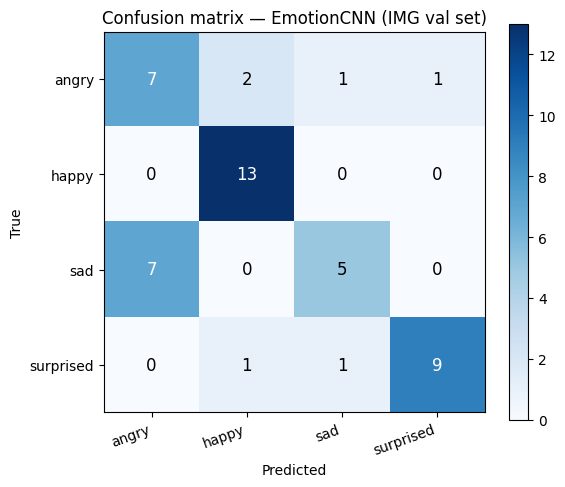

In [47]:
emo_model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for x, y in va_emo_dl:
        x = x.to(DEVICE)
        preds = emo_model(x).argmax(1).cpu().tolist()
        all_true.extend(y.tolist())
        all_pred.extend(preds)

print(classification_report(all_true, all_pred, target_names=EMOTIONS))

cm = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(EMOTIONS, rotation=20, ha='right')
ax.set_yticklabels(EMOTIONS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix — EmotionCNN (IMG val set)')
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
plt.colorbar(im); plt.tight_layout(); plt.show()


"\nindices = list(range(len(val_imgs)))[:n_show]\n\nwith torch.no_grad():\n    for plot_i, idx in enumerate(indices):\n        img_t = emo_val_tf(val_imgs[idx]).unsqueeze(0).to(DEVICE)\n        probs  = torch.softmax(emo_model(img_t), 1)[0].cpu().numpy()\n        pred   = probs.argmax()\n        true   = val_labels[idx]\n        cls_name, fname = val_fnames[idx]\n\n        ax = axes[plot_i]\n        ax.imshow(val_imgs[idx], cmap='gray', aspect='auto')\n        ax.axis('off')\n\n        correct = pred == true\n        border_col = '#27ae60' if correct else '#e74c3c'\n        for spine in ax.spines.values():\n            spine.set_visible(True)\n            spine.set_color(border_col)\n            spine.set_linewidth(3)\n\n        title = f'{EMOTIONS[pred]} ({probs[pred]:.2f})\n[{EMOTIONS[true]}]'\n        ax.set_title(title, fontsize=7,\n                     color='#27ae60' if correct else '#e74c3c', pad=2)\n\n        inset = ax.inset_axes([0, -0.38, 1, 0.3])\n        bars = inset.barh(

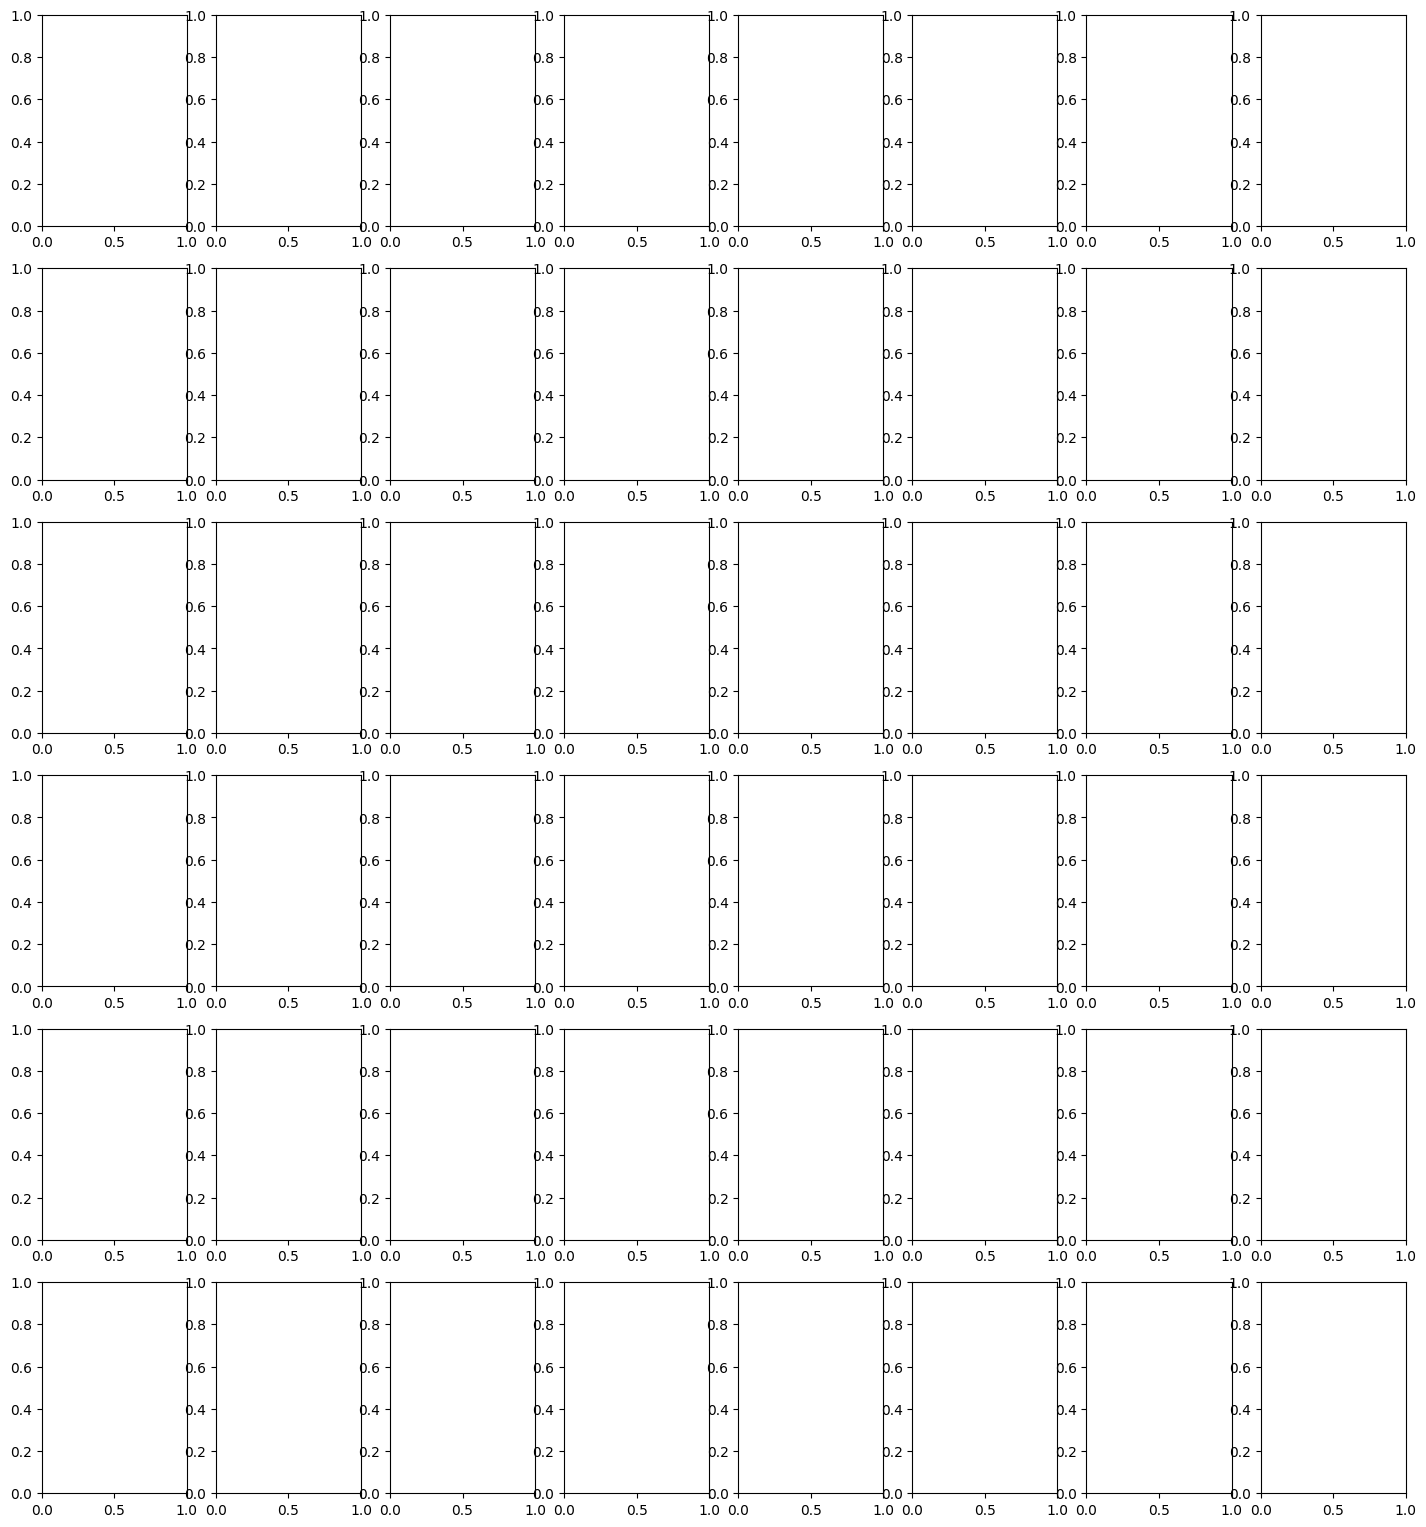

In [53]:
emo_model.eval()
EMO_COLORS_PLOT = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

n_show = min(len(val_imgs), 48)
ncols  = 8
nrows  = (n_show + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 3.2))
axes = axes.flatten()
'''
indices = list(range(len(val_imgs)))[:n_show]

with torch.no_grad():
    for plot_i, idx in enumerate(indices):
        img_t = emo_val_tf(val_imgs[idx]).unsqueeze(0).to(DEVICE)
        probs  = torch.softmax(emo_model(img_t), 1)[0].cpu().numpy()
        pred   = probs.argmax()
        true   = val_labels[idx]
        cls_name, fname = val_fnames[idx]

        ax = axes[plot_i]
        ax.imshow(val_imgs[idx], cmap='gray', aspect='auto')
        ax.axis('off')

        correct = pred == true
        border_col = '#27ae60' if correct else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(border_col)
            spine.set_linewidth(3)

        title = f'{EMOTIONS[pred]} ({probs[pred]:.2f})\n[{EMOTIONS[true]}]'
        ax.set_title(title, fontsize=7,
                     color='#27ae60' if correct else '#e74c3c', pad=2)

        inset = ax.inset_axes([0, -0.38, 1, 0.3])
        bars = inset.barh(range(4), probs, color=EMO_COLORS_PLOT, height=0.7)
        inset.set_xlim(0, 1)
        inset.set_yticks(range(4))
        inset.set_yticklabels([e[:3] for e in EMOTIONS], fontsize=6)
        inset.tick_params(axis='x', labelsize=5)
        inset.axvline(0.5, color='gray', lw=0.5, linestyle='--')

for ax in axes[n_show:]:
    ax.axis('off')

fig.suptitle('Валидация на IMG-фотографиях (зелёная рамка = верно)', fontsize=12)
plt.tight_layout()

# Итоговая точность
correct_count = sum(val_labels[i] == int(probs_list.argmax())
                    for i, probs_list in [(i, torch.softmax(
                        emo_model(emo_val_tf(val_imgs[i]).unsqueeze(0).to(DEVICE)), 1)[0].cpu())
                        for i in range(len(val_imgs))])
print(f'IMG val accuracy: {correct_count}/{len(val_imgs)} = {correct_count/len(val_imgs):.2%}')
'''

In [49]:
torch.save(emo_model.state_dict(), LABS / 'emotion_cnn.pth')
print('Сохранено: emotion_cnn.pth')

Сохранено: emotion_cnn.pth
